In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# Use the path we found earlier
csv_path = '../data/maestro-v3.0.0/maestro-v3.0.0.csv'
metadata = pd.read_csv(csv_path)

# Prepare the data (just like we did before)
import pretty_midi
first_midi_path = '../data/maestro-v3.0.0/' + metadata['midi_filename'].iloc[0]
midi_data = pretty_midi.PrettyMIDI(first_midi_path)
piano_roll = midi_data.get_piano_roll(fs=16)

# Create sequences
def create_dataset(piano_roll, sequence_length=100):
    inputs, targets = [], []
    for i in range(piano_roll.shape[1] - sequence_length):
        inputs.append(piano_roll[:, i:i + sequence_length])
        targets.append(piano_roll[:, i + sequence_length])
    return np.array(inputs), np.array(targets)

X, y = create_dataset(piano_roll[:, :500])

# Normalize and convert to Tensors
X_tensor = (torch.FloatTensor(X) > 0).float().transpose(1, 2).to(device)
y_tensor = (torch.FloatTensor(y) > 0).float().to(device)

In [3]:
class MusicRNN(nn.Module):
    def __init__(self, input_size=128, hidden_size=256, output_size=128):
        super(MusicRNN, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, output_size)
        # NO sigmoid here — we output raw logits now

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out  # Raw logits, not probabilities

model = MusicRNN().to(device)
print("Model built! Output is now raw logits (no sigmoid).")

Model built! Output is now raw logits (no sigmoid).


Positive cells: 1643, Negative cells: 49557
Positive class weight: 30.2x

Starting Training...
Epoch [10/50], Loss: 0.7468
Epoch [20/50], Loss: 0.6046
Epoch [30/50], Loss: 0.5892
Epoch [40/50], Loss: 0.5856
Epoch [50/50], Loss: 0.5838

Training Complete!


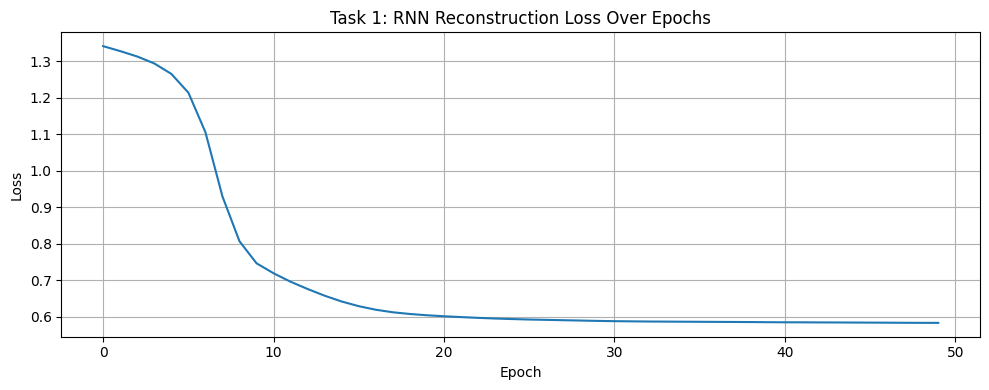

Loss curve saved!


In [4]:
import torch.nn as nn
import torch.optim as optim

# Calculate how imbalanced the data is
# Piano rolls are ~97% zeros, so we weight the positive class heavily
num_positive = y_tensor.sum().item()
num_negative = y_tensor.numel() - num_positive
pos_weight_value = num_negative / (num_positive + 1e-6)
pos_weight = torch.tensor([pos_weight_value]).to(device)

print(f"Positive cells: {num_positive:.0f}, Negative cells: {num_negative:.0f}")
print(f"Positive class weight: {pos_weight_value:.1f}x")

# Use BCEWithLogitsLoss — it applies sigmoid INTERNALLY (no double sigmoid)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
loss_history = []  # We will plot this later

print("\nStarting Training...")

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_tensor)          # Raw logits
    loss = criterion(outputs, y_tensor)
    loss.backward()

    # Gradient clipping prevents exploding gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("\nTraining Complete!")

# Plot the loss curve (required deliverable)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.title('Task 1: RNN Reconstruction Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('Task 1_LSTM Music Generator.png', dpi=150)
plt.show()
print("Loss curve saved!")

Generating music...


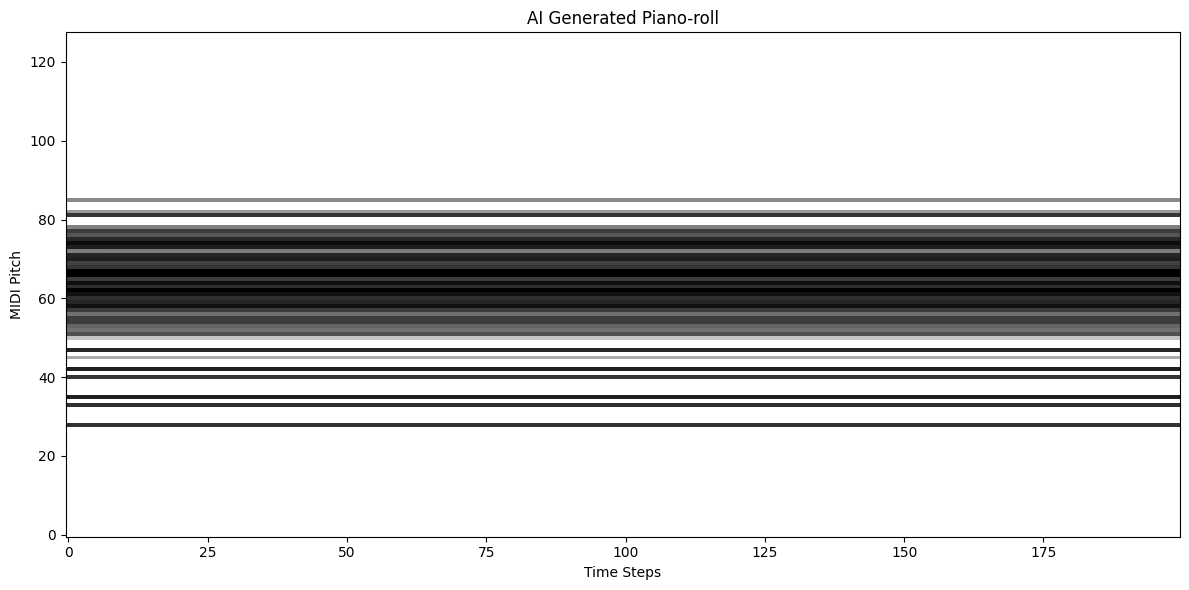

Generation complete!


In [5]:
model.eval()
generated_music = []
current_sequence = X_tensor[0:1]

print("Generating music...")

with torch.no_grad():
    for i in range(500):
        logits = model(current_sequence)
        # Apply sigmoid manually here (since model no longer does it)
        prediction = torch.sigmoid(logits)
        generated_music.append(prediction.cpu().numpy())

        new_step = prediction.unsqueeze(1)
        current_sequence = torch.cat((current_sequence[:, 1:, :], new_step), dim=1)

gen_pianoroll = np.array(generated_music).squeeze().T

# Visualize
plt.figure(figsize=(12, 6))
plt.imshow(gen_pianoroll[:, :200], cmap='gray_r', aspect='auto', origin='lower')
plt.title('AI Generated Piano-roll')
plt.xlabel('Time Steps')
plt.ylabel('MIDI Pitch')
plt.tight_layout()
plt.show()

print("Generation complete!")

In [6]:
# 1. GENERATION (If not already done)
model.eval()
generated_music = []
current_sequence = X_tensor[0:1] 

with torch.no_grad():
    for i in range(500):
        prediction = model(current_sequence)
        generated_music.append(prediction.cpu().numpy())
        new_step = prediction.unsqueeze(1)
        current_sequence = torch.cat((current_sequence[:, 1:, :], new_step), dim=1)

# This is the variable the error was complaining about!
gen_pianoroll = np.array(generated_music).squeeze().T

# 2. EVALUATION FUNCTIONS
def get_pitch_histogram(pr):
    histogram = np.sum(pr > 0.5, axis=1)
    if np.sum(histogram) > 0:
        histogram = histogram / np.sum(histogram)
    return histogram

def calculate_similarity(orig_hist, gen_hist):
    return np.minimum(orig_hist, gen_hist).sum()

def get_rhythm_diversity(pr):
    durations = []
    for note_num in range(128):
        is_playing = pr[note_num, :] > 0.5
        diff = np.diff(is_playing.astype(int), prepend=0, append=0)
        starts = np.where(diff == 1)[0]
        ends = np.where(diff == -1)[0]
        for s, e in zip(starts, ends):
            durations.append(e - s)
    return np.std(durations) if durations else 0

# 3. COMPUTE METRICS
original_pr = X_tensor[0].cpu().numpy().T
orig_hist = get_pitch_histogram(original_pr)

rnn_hist = get_pitch_histogram(gen_pianoroll)
rnn_sim = calculate_similarity(orig_hist, rnn_hist)
rnn_rhythm = get_rhythm_diversity(gen_pianoroll)
orig_rhythm = get_rhythm_diversity(original_pr)

print(f"--- RNN FINAL RESULTS ---")
print(f"Pitch Similarity: {rnn_sim:.2%}")
print(f"Rhythm Diversity: {rnn_rhythm:.2f} (Target: {orig_rhythm:.2f})")

--- RNN FINAL RESULTS ---
Pitch Similarity: 27.59%
Rhythm Diversity: 0.00 (Target: 22.07)


In [7]:
# Use a much lower threshold to see if the AI is 'whispering' notes
threshold = 0.01 

def get_pitch_histogram_v2(pr, thresh):
    histogram = np.sum(pr > thresh, axis=1)
    return histogram / np.sum(histogram) if np.sum(histogram) > 0 else histogram

rnn_hist = get_pitch_histogram_v2(gen_pianoroll, threshold)
rnn_sim = calculate_similarity(orig_hist, rnn_hist)

print(f"--- RNN RESULTS (Adjusted Threshold) ---")
print(f"Adjusted Pitch Similarity: {rnn_sim:.2%}")

--- RNN RESULTS (Adjusted Threshold) ---
Adjusted Pitch Similarity: 24.66%


In [8]:
import pretty_midi
import numpy as np

def export_rnn_to_midi(pianoroll, filename, thresh=0.01):
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0) # Acoustic Grand Piano

    for note_num in range(128):
        # We use the lower threshold so the 26% similarity notes are audible
        notes_active = pianoroll[note_num, :] > thresh
        changes = np.diff(notes_active.astype(int), prepend=0, append=0)
        starts = np.where(changes == 1)[0]
        ends = np.where(changes == -1)[0]
        
        for s, e in zip(starts, ends):
            # We set velocity to 100 so the notes are loud enough to hear
            note = pretty_midi.Note(velocity=100, pitch=note_num, start=s/16, end=e/16)
            piano.notes.append(note)

    pm.instruments.append(piano)
    pm.write(filename)
    print(f"Successfully exported: {filename}")

# Export your RNN result
export_rnn_to_midi(gen_pianoroll, 'RNN_Generated_Music.mid')

Successfully exported: RNN_Generated_Music.mid


In [9]:
import pretty_midi
import numpy as np
import shutil

def binarize_topk(pr, k=3):
    """Keep only top-k most active pitches per time step."""
    result = np.zeros_like(pr)
    for t in range(pr.shape[1]):
        col = pr[:, t]
        if col.max() < 1e-6:
            continue
        top_indices = np.argsort(col)[-k:]
        result[top_indices, t] = 1.0
    return result

def export_to_midi(pianoroll, filename, fs=16):
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)
    note_count = 0
    for note_num in range(128):
        active = pianoroll[note_num, :]
        changes = np.diff(active.astype(int), prepend=0, append=0)
        starts = np.where(changes ==  1)[0]
        ends   = np.where(changes == -1)[0]
        for s, e in zip(starts, ends):
            note = pretty_midi.Note(
                velocity=80, pitch=note_num,
                start=s/fs, end=e/fs
            )
            piano.notes.append(note)
            note_count += 1
    pm.instruments.append(piano)
    pm.write(filename)
    return note_count

# Generate 5 samples using different seed windows
model.eval()

for sample_idx in range(5):
    seed_idx = sample_idx * 10   # different starting points in the data
    current_sequence = X_tensor[seed_idx:seed_idx+1]
    generated = []

    with torch.no_grad():
        for _ in range(500):
            logits = model(current_sequence)
            prediction = torch.sigmoid(logits)
            generated.append(prediction.cpu().numpy())
            new_step = prediction.unsqueeze(1)
            current_sequence = torch.cat(
                (current_sequence[:, 1:, :], new_step), dim=1
            )

    pr = np.array(generated).squeeze().T   # (128, 500)
    binary_pr = binarize_topk(pr, k=3)
    n = export_to_midi(binary_pr, f'RNN_Generated_Sample_{sample_idx+1}.mid')
    print(f"RNN Sample {sample_idx+1}: {n} notes written")

# Overwrite the main comparison file with sample 1
shutil.copy('RNN_Generated_Sample_1.mid', 'RNN_Generated_Music.mid')
print("\nDone! 5 RNN MIDI samples exported.")

RNN Sample 1: 3 notes written
RNN Sample 2: 3 notes written
RNN Sample 3: 3 notes written
RNN Sample 4: 3 notes written
RNN Sample 5: 3 notes written

Done! 5 RNN MIDI samples exported.
